In [2]:
%pip install numpy

  Using cached numpy-2.5.2-cp314-cp314-macosx_14_0_arm64.whl.metadata (6.6 kB)
Using cached numpy-2.5.2-cp314-cp314-macosx_14_0_arm64.whl (5.4 MB)
Note: you may need to restart the kernel to use updated packages.


In [3]:
%pip install pandas matplotlib

  Using cached pandas-3.0.5-cp314-cp314-macosx_11_0_arm64.whl.metadata (79 kB)
  Using cached matplotlib-3.11.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (80 kB)
  Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.64.0-cp314-cp314-macosx_10_15_universal2.whl.metadata (123 kB)
  Using cached kiwisolver-1.5.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-macosx_11_0_arm64.whl.metadata (9.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached pandas-3.0.5-cp314-cp314-macosx_11_0_arm64.whl (10.0 MB)
Using cached matplotlib-3.11.1-cp314-cp314-macosx_11_0_arm64.whl (9.3 MB)
Using cached contourpy-1.3.3-cp314-cp314-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.64.0-cp314-cp314-macosx_10_15_universal2.whl (3.1 MB)
Using cached kiwisolv

In [6]:
%pip install yfinance scikit-learn torch

  Using cached yfinance-1.7.0-py3-none-any.whl.metadata (6.7 kB)
  Using cached scikit_learn-1.9.0-cp314-cp314-macosx_12_0_arm64.whl.metadata (11 kB)
  Using cached torch-2.14.0-cp314-cp314-macosx_14_0_arm64.whl.metadata (39 kB)
  Using cached curl_cffi-0.16.3-cp310-abi3-macosx_11_0_arm64.whl.metadata (17 kB)
  Using cached lxml-6.1.3-cp314-cp314-macosx_10_15_universal2.whl.metadata (3.3 kB)
  Using cached multitasking-0.0.13-py3-none-any.whl.metadata (16 kB)
  Using cached peewee-4.4.0-py3-none-any.whl.metadata (10 kB)
  Using cached protobuf-7.36.1-cp310-abi3-macosx_10_9_universal2.whl.metadata (595 bytes)
  Using cached pytz-2026.3.post1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached websockets-17.1-cp314-cp314-macosx_11_0_arm64.whl.metadata (6.3 kB)
  Using cached scipy-1.18.1-cp314-cp314-macosx_14_0_arm64.whl.metadata (62 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached narwhals-2.25.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpo

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error

Matplotlib is building the font cache; this may take a moment.


In [135]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [204]:
ticker = 'INTL'
df = yf.download(ticker, '2025-01-01')

[*********************100%***********************]  1 of 1 completed


In [205]:
df

Price,Close,High,Low,Open,Volume
Ticker,INTL,INTL,INTL,INTL,INTL
Date,,,,,
2025-01-02,21.254747,21.361822,21.219055,21.318413,62500
2025-01-03,21.424522,21.430311,21.308767,21.308767,5600
2025-01-06,21.636742,21.877900,21.607802,21.877900,83600
2025-01-07,21.518093,21.762146,21.511341,21.762146,4100
2025-01-08,21.452497,21.452497,21.356998,21.356998,12500
...,...,...,...,...,...
2026-08-31,31.320000,31.440001,31.250000,31.250000,9000
2026-09-01,31.024000,31.239000,30.950001,31.200001,14900


<Axes: xlabel='Date'>

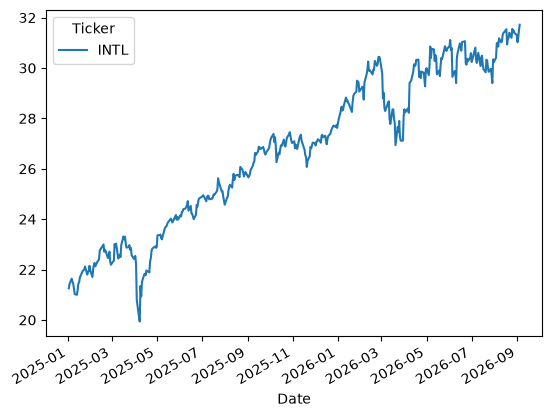

In [206]:
df.Close.plot()

In [207]:
scaler = StandardScaler()

df['Close'] = scaler.fit_transform(df[['Close']])

In [208]:
df.Close

Ticker,INTL
Date,
2025-01-02,-1.786764
2025-01-03,-1.731426
2025-01-06,-1.662254
2025-01-07,-1.700927
2025-01-08,-1.722308
...,...
2026-08-31,1.493963
2026-09-01,1.397483
2026-09-02,1.456479


In [209]:
seq_length = 90
data = []

for i in range(len(df) - seq_length):
    data.append(df.Close[i: i + seq_length])

data = np.array(data)


In [210]:
train_size = int(0.8 * len(data))

X_train = torch.from_numpy(data[:train_size, :-1, :]).type(torch.Tensor).to(device)
Y_train = torch.from_numpy(data[:train_size, -1, :]).type(torch.Tensor).to(device)
X_test = torch.from_numpy(data[train_size:, :-1, :]).type(torch.Tensor).to(device)
Y_test = torch.from_numpy(data[train_size:, -1, :]).type(torch.Tensor).to(device)

In [211]:
class PredictionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(PredictionModel, self).__init__()
        self.num_layers = num_layers
        self.hidden_dim = hidden_dim

        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first = True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim, device=device)

        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :])

        return out

In [212]:
model = PredictionModel(input_dim = 1, hidden_dim = 32, num_layers = 2, output_dim = 1).to(device)

In [213]:
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.03)

In [214]:
num_epochs = 220

for i in range(num_epochs):
    y_train_pred = model(X_train)

    loss = criterion(y_train_pred, Y_train)

    if i % 10 == 0:
        print(i, loss.item())
        
    optimizer.zero_grad()
    
    loss.backward()
    
    optimizer.step()

0 0.4305208623409271
10 0.05378848314285278
20 0.026487108319997787
30 0.013230334967374802
40 0.009181680157780647
50 0.008205009624361992
60 0.007928059436380863
70 0.007574794813990593
80 0.007484980393201113
90 0.007414935156702995
100 0.0073640779592096806
110 0.007334094028919935
120 0.007308913394808769
130 0.007287619169801474
140 0.007268313784152269
150 0.007249773945659399
160 0.0072312806732952595
170 0.007212281227111816
180 0.007192410062998533
190 0.007171496283262968
200 0.007149448152631521
210 0.00712608452886343


In [215]:
model.eval()

y_test_pred=model(X_test)

y_train_pred = scaler.inverse_transform(y_train_pred.detach().numpy())
Y_train = scaler.inverse_transform(Y_train)
y_test_pred = scaler.inverse_transform(y_test_pred.detach().cpu().numpy())
Y_test = scaler.inverse_transform(Y_test)

In [216]:
train_rmse = root_mean_squared_error(Y_train[:, 0], y_train_pred[:, 0])
test_rmse = root_mean_squared_error(Y_test[:, 0], y_test_pred[:, 0])

In [217]:
train_rmse

0.2585800376351883

In [218]:
test_rmse

0.3953477701178219

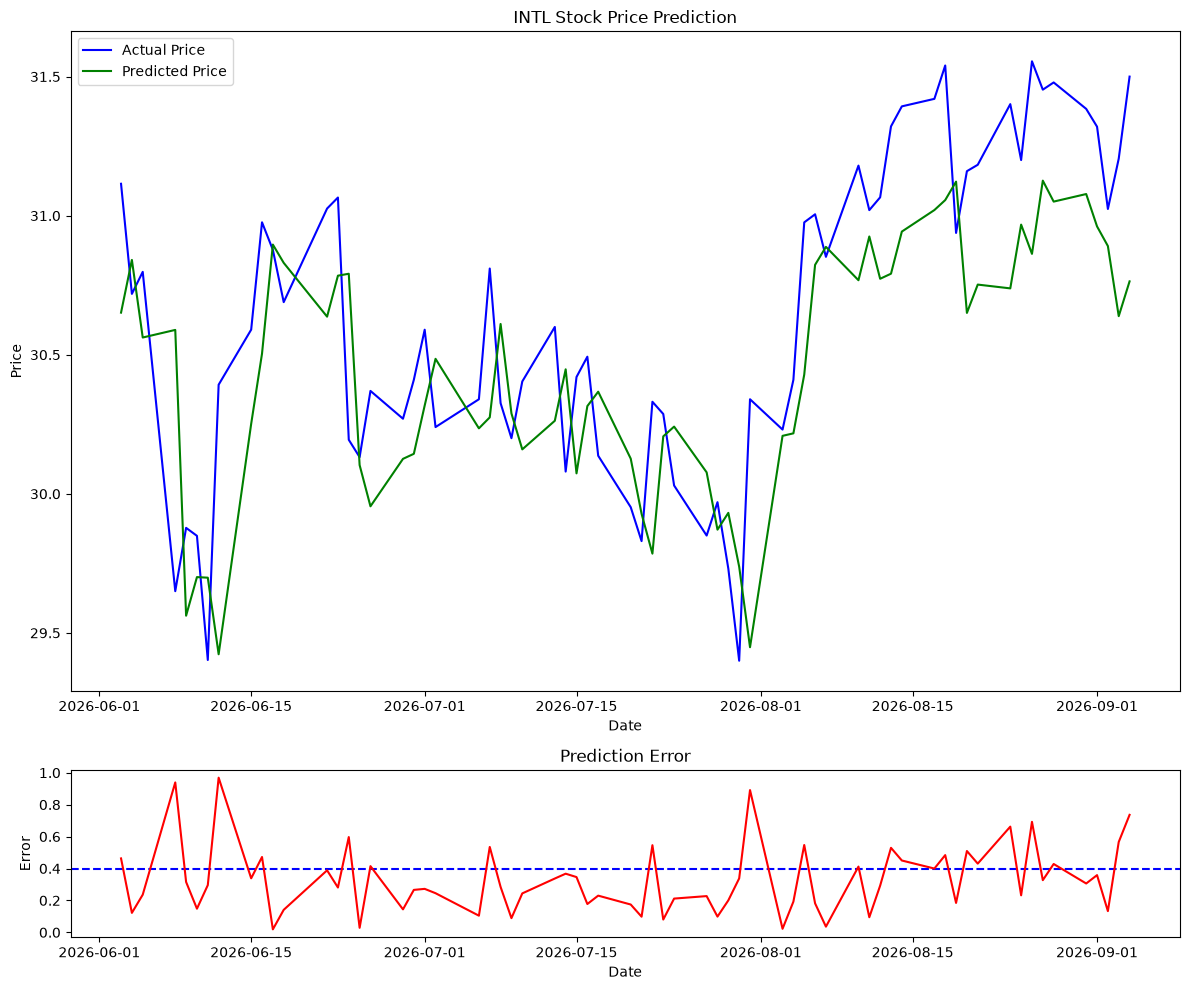

In [219]:
fig = plt.figure(figsize=(12, 10))
gs = fig.add_gridspec(4, 1)
ax1 = fig.add_subplot(gs[:3, 0])
ax1.plot(df.iloc[-len(Y_test):].index, Y_test, color='blue', label = 'Actual Price')
ax1.plot(df.iloc[-len(Y_test):].index, y_test_pred, color='green', label = 'Predicted Price')
ax1.legend()
plt.title(f"{ticker} Stock Price Prediction")
plt.xlabel("Date")
plt.ylabel("Price")

ax2 = fig.add_subplot(gs[3, 0])
ax2.axhline(test_rmse, color = 'blue', linestyle ='--', label = 'RMSE')
ax2.plot(df.iloc[-len(Y_test):].index, abs(Y_test - y_test_pred), 'r', label = 'Prediction Error')
ax2.legend
plt.title('Prediction Error')
plt.xlabel('Date')
plt.ylabel('Error')
plt.tight_layout()
plt.show()